✅ Working directory: /Users/progressive/Documents/Courses/Final-Year-Disease-Prediction
✅ Weather shape: (220, 5)
✅ Cholera shape: (16, 2)

✅ Merged shape: (192, 6)
Years: 2010 to 2025

✅ Cholera median: 7386 cases/year
✅ High severity years: [2010 2011 2014 2019 2021 2022 2023 2024]
✅ High risk months: 48
✅ Low risk months:  144

✅ Final dataset shape: (190, 14)
✅ Class distribution: {0: 142, 1: 48}
✅ Weather features:   ['temperature_c', 'humidity_pct', 'wind_speed', 'temp_lag1', 'humidity_lag1', 'wind_lag1']
✅ Seasonal features:  ['month', 'rainy_season', 'temp_lag2', 'humidity_lag2']
✅ Features scaled

=== TRADITIONAL MODELS (5-Fold Stratified CV) ===

Logistic Regression:
  Accuracy:  74.74% (+/- 6.78%)
  F1 Score:  67.17% (+/- 6.90%)
  Recall:    100.00% (+/- 0.00%)
  Precision: 51.00% (+/- 8.30%)

Random Forest:
  Accuracy:  70.53% (+/- 4.82%)
  F1 Score:  54.73% (+/- 7.19%)
  Recall:    73.33% (+/- 20.76%)
  Precision: 46.25% (+/- 6.74%)

XGBoost:
  Accuracy:  72.63% (+/- 8.90%

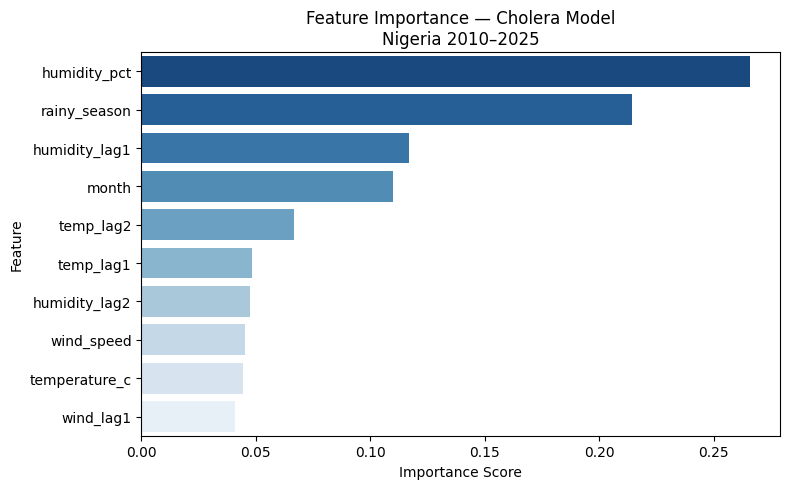

✅ Feature importance chart saved!


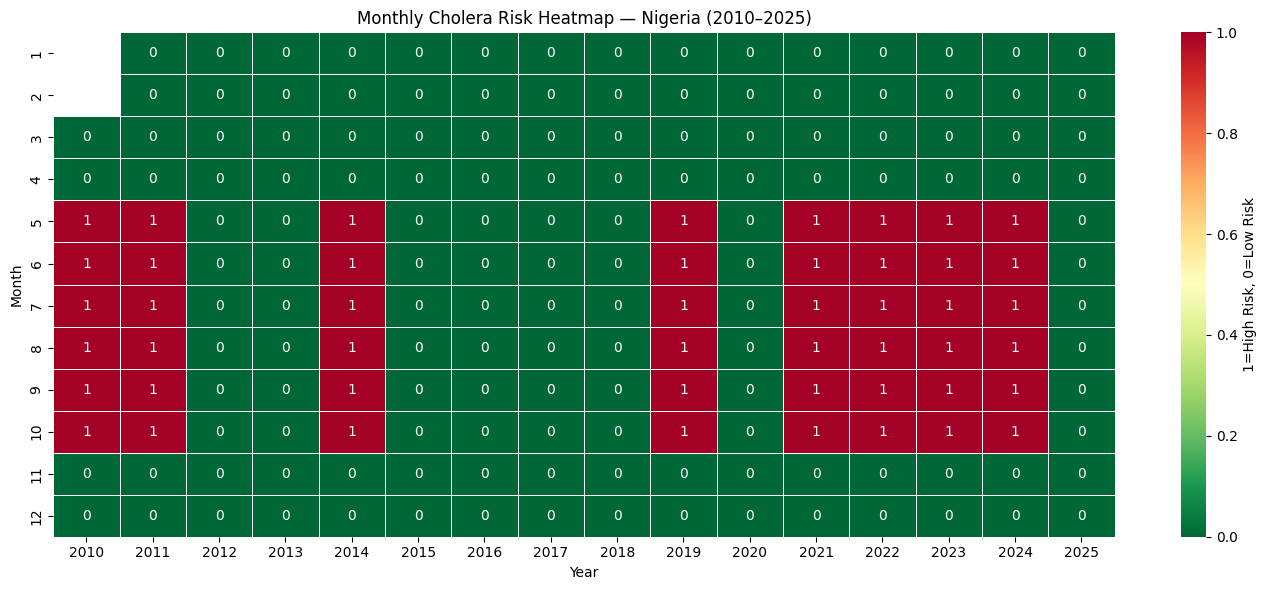

✅ Risk heatmap saved!


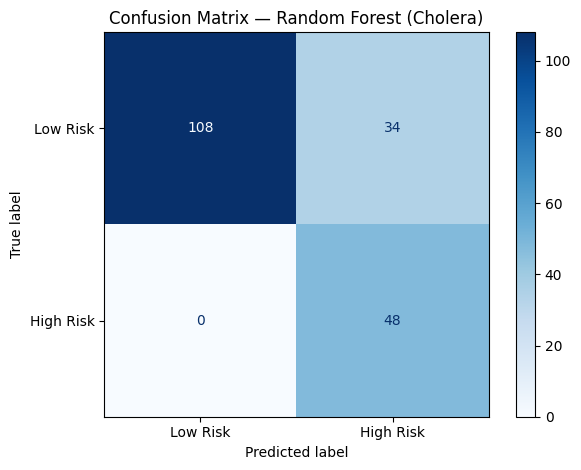

✅ Confusion matrix saved!
✅ Cholera models saved!

CHOLERA MODEL — FINAL COMPARISON
Model                              Accuracy         F1     Recall
-----------------------------------------------------------------
Logistic Regression                  74.74%     67.17%    100.00%
Random Forest                        70.53%     54.73%     73.33%
XGBoost                              72.63%     45.39%     43.33%
Neural Network (Multi-Input)         71.58%     56.91%     79.11%
Ensemble (LR+RF+XGB)                 71.05%     54.47%     68.89%

Dataset:  Nigeria Cholera only
Period:   2010 to 2025
Rows:     190 monthly observations
Median threshold: 7386 cases/year


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             f1_score, recall_score, precision_score)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
import warnings
warnings.filterwarnings('ignore')

os.chdir('/Users/progressive/Documents/Courses/Final-Year-Disease-Prediction')
print("✅ Working directory:", os.getcwd())

# ── 1. Load data ───────────────────────────────────────────────────
df_weather = pd.read_csv('data/processed/era5_nigeria_v2_monthly.csv')
df_cholera = pd.read_csv('data/raw/nigeria_cholera.csv')

print("✅ Weather shape:", df_weather.shape)
print("✅ Cholera shape:", df_cholera.shape)

# ── 2. Merge on year ───────────────────────────────────────────────
df = pd.merge(df_weather, df_cholera, on='year', how='inner')
print("\n✅ Merged shape:", df.shape)
print("Years:", df['year'].min(), "to", df['year'].max())

# ── 3. Create target variable ──────────────────────────────────────
df['rainy_season'] = df['month'].between(5, 10).astype(int)

median_cholera = df['cholera_cases'].median()
df['high_severity_year'] = (
    df['cholera_cases'] > median_cholera
).astype(int)

df['high_risk'] = (
    (df['rainy_season'] == 1) &
    (df['high_severity_year'] == 1)
).astype(int)

print(f"\n✅ Cholera median: {median_cholera:.0f} cases/year")
print(f"✅ High severity years: {df[df['high_severity_year']==1]['year'].unique()}")
print(f"✅ High risk months: {df['high_risk'].sum()}")
print(f"✅ Low risk months:  {(df['high_risk']==0).sum()}")

# ── 4. Add lag features ────────────────────────────────────────────
df = df.sort_values(['year','month']).reset_index(drop=True)
df['temp_lag1']     = df['temperature_c'].shift(1)
df['humidity_lag1'] = df['humidity_pct'].shift(1)
df['temp_lag2']     = df['temperature_c'].shift(2)
df['humidity_lag2'] = df['humidity_pct'].shift(2)
df['wind_lag1']     = df['wind_speed'].shift(1)
df = df.dropna().reset_index(drop=True)

print(f"\n✅ Final dataset shape: {df.shape}")

# ── 5. Feature groups ──────────────────────────────────────────────
weather_features  = ['temperature_c', 'humidity_pct', 'wind_speed',
                     'temp_lag1', 'humidity_lag1', 'wind_lag1']
seasonal_features = ['month', 'rainy_season', 'temp_lag2', 'humidity_lag2']
all_features      = weather_features + seasonal_features

X_all      = df[all_features].values
X_weather  = df[weather_features].values
X_seasonal = df[seasonal_features].values
y          = df['high_risk']

print(f"✅ Class distribution: {y.value_counts().to_dict()}")
print(f"✅ Weather features:   {weather_features}")
print(f"✅ Seasonal features:  {seasonal_features}")

# ── 6. Scale features ──────────────────────────────────────────────
scaler_all      = StandardScaler()
scaler_weather  = StandardScaler()
scaler_seasonal = StandardScaler()

X_all_scaled      = scaler_all.fit_transform(X_all)
X_weather_scaled  = scaler_weather.fit_transform(X_weather)
X_seasonal_scaled = scaler_seasonal.fit_transform(X_seasonal)
print("✅ Features scaled")

# ── 7. Cross validation ────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 8. Traditional models ──────────────────────────────────────────
traditional_models = {
    'Logistic Regression': LogisticRegression(
                               max_iter=1000,
                               class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(
                               n_estimators=200, max_depth=5,
                               random_state=42,
                               class_weight='balanced'),
    'XGBoost':             XGBClassifier(
                               n_estimators=200, max_depth=4,
                               learning_rate=0.1, random_state=42,
                               scale_pos_weight=len(y[y==0])/len(y[y==1]),
                               eval_metric='logloss', verbosity=0),
}

print("\n=== TRADITIONAL MODELS (5-Fold Stratified CV) ===")
trad_results = {}
for name, model in traditional_models.items():
    acc = cross_val_score(model, X_all_scaled, y, cv=cv, scoring='accuracy')
    f1  = cross_val_score(model, X_all_scaled, y, cv=cv, scoring='f1')
    rec = cross_val_score(model, X_all_scaled, y, cv=cv, scoring='recall')
    pre = cross_val_score(model, X_all_scaled, y, cv=cv, scoring='precision')
    trad_results[name] = {
        'Accuracy': acc.mean(), 'F1': f1.mean(),
        'Recall': rec.mean(), 'Precision': pre.mean()
    }
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc.mean():.2%} (+/- {acc.std():.2%})")
    print(f"  F1 Score:  {f1.mean():.2%} (+/- {f1.std():.2%})")
    print(f"  Recall:    {rec.mean():.2%} (+/- {rec.std():.2%})")
    print(f"  Precision: {pre.mean():.2%} (+/- {pre.std():.2%})")

# ── 9. Multi-Input Neural Network ─────────────────────────────────
print("\n=== MULTI-INPUT NEURAL NETWORK ===")

class MultiInputNet(nn.Module):
    def __init__(self, weather_dim, seasonal_dim):
        super().__init__()
        self.weather_branch = nn.Sequential(
            nn.Linear(weather_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),          nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16),          nn.ReLU(),
        )
        self.seasonal_branch = nn.Sequential(
            nn.Linear(seasonal_dim, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16),           nn.ReLU(),
        )
        self.combined = nn.Sequential(
            nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1),  nn.Sigmoid()
        )
    def forward(self, xw, xs):
        return self.combined(
            torch.cat([self.weather_branch(xw),
                       self.seasonal_branch(xs)], dim=1)
        ).squeeze()

nn_scores = {'accuracy':[], 'f1':[], 'recall':[], 'precision':[]}

for fold, (train_idx, val_idx) in enumerate(cv.split(X_weather_scaled, y)):
    Xw_tr = torch.FloatTensor(X_weather_scaled[train_idx])
    Xs_tr = torch.FloatTensor(X_seasonal_scaled[train_idx])
    y_tr  = torch.FloatTensor(y.values[train_idx])
    Xw_v  = torch.FloatTensor(X_weather_scaled[val_idx])
    Xs_v  = torch.FloatTensor(X_seasonal_scaled[val_idx])
    y_v   = y.values[val_idx]

    net  = MultiInputNet(len(weather_features), len(seasonal_features))
    opt  = optim.Adam(net.parameters(), lr=0.001, weight_decay=1e-4)
    crit = nn.BCELoss()

    net.train()
    for _ in range(200):
        opt.zero_grad()
        loss = crit(net(Xw_tr, Xs_tr), y_tr)
        loss.backward()
        opt.step()

    net.eval()
    with torch.no_grad():
        preds = (net(Xw_v, Xs_v).numpy() >= 0.5).astype(int)

    nn_scores['accuracy'].append(accuracy_score(y_v, preds))
    nn_scores['f1'].append(f1_score(y_v, preds, zero_division=0))
    nn_scores['recall'].append(recall_score(y_v, preds, zero_division=0))
    nn_scores['precision'].append(precision_score(y_v, preds, zero_division=0))
    print(f"  Fold {fold+1}: Acc={nn_scores['accuracy'][-1]:.2%} "
          f"F1={nn_scores['f1'][-1]:.2%} "
          f"Recall={nn_scores['recall'][-1]:.2%}")

nn_results = {k: np.mean(v) for k, v in nn_scores.items()}
print(f"\n  Mean — Accuracy: {nn_results['accuracy']:.2%} "
      f"F1: {nn_results['f1']:.2%} "
      f"Recall: {nn_results['recall']:.2%}")

# ── 10. Ensemble ───────────────────────────────────────────────────
print("\n=== ENSEMBLE MODEL (LR + RF + XGB) ===")
ensemble = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced')),
        ('rf',  RandomForestClassifier(n_estimators=200, max_depth=5,
                    random_state=42, class_weight='balanced')),
        ('xgb', XGBClassifier(n_estimators=200, max_depth=4,
                    learning_rate=0.1, random_state=42,
                    scale_pos_weight=len(y[y==0])/len(y[y==1]),
                    eval_metric='logloss', verbosity=0)),
    ], voting='soft'
)

ens_acc = cross_val_score(ensemble, X_all_scaled, y, cv=cv, scoring='accuracy')
ens_f1  = cross_val_score(ensemble, X_all_scaled, y, cv=cv, scoring='f1')
ens_rec = cross_val_score(ensemble, X_all_scaled, y, cv=cv, scoring='recall')
ens_pre = cross_val_score(ensemble, X_all_scaled, y, cv=cv, scoring='precision')

print(f"  Accuracy:  {ens_acc.mean():.2%} (+/- {ens_acc.std():.2%})")
print(f"  F1 Score:  {ens_f1.mean():.2%} (+/- {ens_f1.std():.2%})")
print(f"  Recall:    {ens_rec.mean():.2%} (+/- {ens_rec.std():.2%})")
print(f"  Precision: {ens_pre.mean():.2%} (+/- {ens_pre.std():.2%})")

# ── 11. Feature importance ─────────────────────────────────────────
rf_final = RandomForestClassifier(
    n_estimators=200, max_depth=5,
    random_state=42, class_weight='balanced'
)
rf_final.fit(X_all_scaled, y)

feat_df = pd.DataFrame({
    'Feature':    all_features,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n✅ Feature Importance:")
print(feat_df.to_string(index=False))

# ── 12. Charts ─────────────────────────────────────────────────────
os.makedirs('outputs/figures', exist_ok=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance — Cholera Model\nNigeria 2010–2025')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/figures/cholera_feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance chart saved!")

# Risk heatmap
pivot = df.pivot_table(
    values='high_risk', index='month',
    columns='year', aggfunc='mean'
)
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5,
            cbar_kws={'label': '1=High Risk, 0=Low Risk'})
plt.title('Monthly Cholera Risk Heatmap — Nigeria (2010–2025)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.savefig('outputs/figures/cholera_risk_heatmap.png', dpi=150)
plt.show()
print("✅ Risk heatmap saved!")

# Confusion matrix
y_pred = rf_final.predict(X_all_scaled)
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=['Low Risk', 'High Risk'],
    cmap='Blues'
)
plt.title('Confusion Matrix — Random Forest (Cholera)')
plt.tight_layout()
plt.savefig('outputs/figures/cholera_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

# ── 13. Save models ────────────────────────────────────────────────
ensemble.fit(X_all_scaled, y)
joblib.dump(ensemble,   'outputs/cholera_ensemble_model.pkl')
joblib.dump(scaler_all, 'outputs/cholera_scaler.pkl')
print("✅ Cholera models saved!")

# ── 14. Final summary ──────────────────────────────────────────────
print("\n" + "="*65)
print("CHOLERA MODEL — FINAL COMPARISON")
print("="*65)
print(f"{'Model':<32} {'Accuracy':>10} {'F1':>10} {'Recall':>10}")
print("-"*65)
for name, res in trad_results.items():
    print(f"{name:<32} {res['Accuracy']:>10.2%} "
          f"{res['F1']:>10.2%} {res['Recall']:>10.2%}")
print(f"{'Neural Network (Multi-Input)':<32} "
      f"{nn_results['accuracy']:>10.2%} "
      f"{nn_results['f1']:>10.2%} "
      f"{nn_results['recall']:>10.2%}")
print(f"{'Ensemble (LR+RF+XGB)':<32} "
      f"{ens_acc.mean():>10.2%} "
      f"{ens_f1.mean():>10.2%} "
      f"{ens_rec.mean():>10.2%}")
print("="*65)
print(f"\nDataset:  Nigeria Cholera only")
print(f"Period:   {df['year'].min()} to {df['year'].max()}")
print(f"Rows:     {len(df)} monthly observations")
print(f"Median threshold: {median_cholera:.0f} cases/year")